# Week 6–7 Practice Exercise: Solution Key

**Stationarity, Unit Root Tests, Differencing, AR/MA/ARMA**

This notebook implements the full pipeline on the healthcare time series: load → ADF → differencing → ACF/PACF → ARIMA fit → residual diagnostics and forecast evaluation.

## 1. Setup and data load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.rcParams['figure.figsize'] = (10, 4)

In [2]:
df = pd.read_csv("data/healthcare_ts.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").sort_index()
y = df["value"]

print("Shape:", df.shape)
print("Date range:", df.index.min(), "to", df.index.max())
print("\nDescribe:")
print(y.describe())
y.head()

Shape: (730, 1)
Date range: 2022-01-01 00:00:00 to 2023-12-31 00:00:00

Describe:
count    730.000000
mean     314.353244
std      282.914581
min     -219.414735
25%       86.768331
50%      354.026345
75%      541.070767
max      883.778694
Name: value, dtype: float64


date
2022-01-01     86.760570
2022-01-02     89.527740
2022-01-03     99.300305
2022-01-04    123.780202
2022-01-05    135.998300
Name: value, dtype: float64

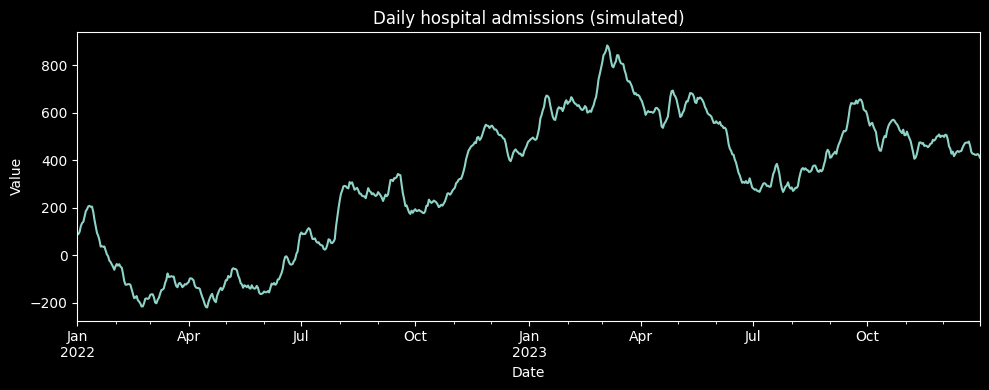

In [3]:
y.plot(title="Daily hospital admissions (simulated)", xlabel="Date", ylabel="Value")
plt.tight_layout()
plt.show()

## 2. Unit root tests (ADF on raw series)

In [4]:
adf_raw = adfuller(y, autolag="AIC")
print("Augmented Dickey-Fuller test (raw series):")
print("  Test statistic:", round(adf_raw[0], 4))
print("  p-value:", round(adf_raw[1], 4))
print("  Critical values:", adf_raw[4])
if adf_raw[1] > 0.05:
    print("  Conclusion: Do not reject H0 → series has a unit root (non-stationary).")
else:
    print("  Conclusion: Reject H0 → series is stationary.")

Augmented Dickey-Fuller test (raw series):
  Test statistic: -1.4159
  p-value: 0.5746
  Critical values: {'1%': np.float64(-3.4393644334758475), '5%': np.float64(-2.8655182850048306), '10%': np.float64(-2.568888486973192)}
  Conclusion: Do not reject H0 → series has a unit root (non-stationary).


## 3. Differencing

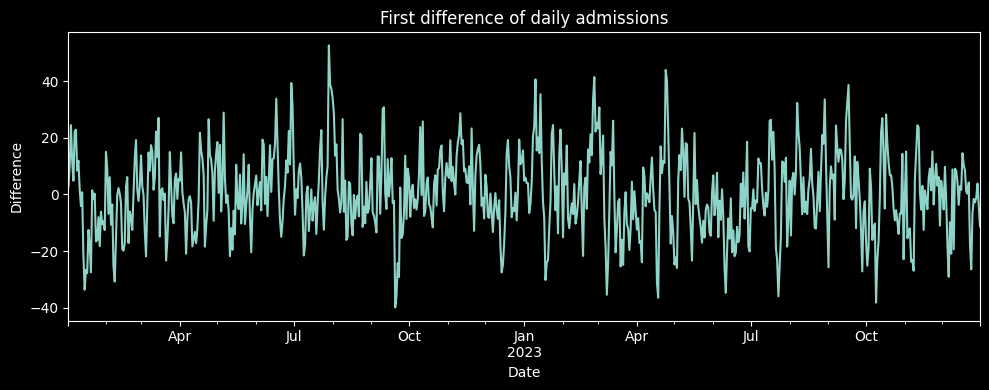

In [5]:
dy = y.diff().dropna()
dy.plot(title="First difference of daily admissions", xlabel="Date", ylabel="Difference")
plt.tight_layout()
plt.show()

In [6]:
adf_diff = adfuller(dy, autolag="AIC")
print("Augmented Dickey-Fuller test (differenced series):")
print("  Test statistic:", round(adf_diff[0], 4))
print("  p-value:", round(adf_diff[1], 4))
if adf_diff[1] <= 0.05:
    print("  Conclusion: Reject H0 → differenced series is stationary. Use d = 1.")

Augmented Dickey-Fuller test (differenced series):
  Test statistic: -14.0519
  p-value: 0.0
  Conclusion: Reject H0 → differenced series is stationary. Use d = 1.


## 4. ACF and PACF for model selection

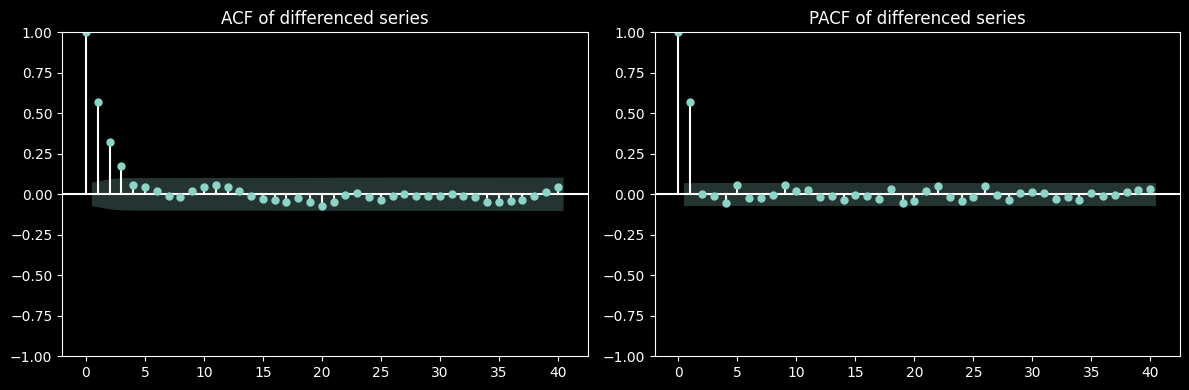

Interpretation: PACF cuts off after lag 1 → suggest AR(1) on diff. ACF decays.
Suggested order for original series: ARIMA(1, 1, 0). Also try (0,1,1) and (1,1,1).


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(dy, lags=40, ax=axes[0], title="ACF of differenced series")
plot_pacf(dy, lags=40, ax=axes[1], title="PACF of differenced series", method="ywm")
plt.tight_layout()
plt.show()
print("Interpretation: PACF cuts off after lag 1 → suggest AR(1) on diff. ACF decays.")
print("Suggested order for original series: ARIMA(1, 1, 0). Also try (0,1,1) and (1,1,1).")

## 5. AR/MA/ARMA fit

In [8]:
orders = [(1, 1, 0), (0, 1, 1), (1, 1, 1)]
results = {}
for order in orders:
    model = ARIMA(y, order=order)
    fit = model.fit()
    results[order] = fit
    print(f"ARIMA{order}: AIC = {fit.aic:.2f}, BIC = {fit.bic:.2f}")
    print(f"  Params: {fit.params.to_dict()}")
    print()

ARIMA(1, 1, 0): AIC = 5671.77, BIC = 5680.95
  Params: {'ar.L1': 0.5715584227251254, 'sigma2': 139.25295349216597}

ARIMA(0, 1, 1): AIC = 5736.84, BIC = 5746.02
  Params: {'ma.L1': 0.4922949898887162, 'sigma2': 152.27878427536913}

ARIMA(1, 1, 1): AIC = 5673.77, BIC = 5687.54
  Params: {'ar.L1': 0.5705872415629494, 'ma.L1': 0.0014383447761781754, 'sigma2': 139.25197742786855}



/Users/nguyennghia/miniconda3/envs/vitaldb/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/nguyennghia/miniconda3/envs/vitaldb/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/nguyennghia/miniconda3/envs/vitaldb/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/nguyennghia/miniconda3/envs/vitaldb/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/nguyennghia/miniconda3/envs/vitaldb/lib/python3.10/site-p

In [9]:
best_order = min(results, key=lambda k: results[k].bic)
fit_best = results[best_order]
print(f"Preferred model by BIC: ARIMA{best_order}")
print(fit_best.summary())

Preferred model by BIC: ARIMA(1, 1, 0)
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  730
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -2833.884
Date:                Tue, 03 Feb 2026   AIC                           5671.768
Time:                        11:30:43   BIC                           5680.951
Sample:                    01-01-2022   HQIC                          5675.311
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5716      0.031     18.666      0.000       0.512       0.632
sigma2       139.2530      6.990     19.920      0.000     125.552     152.954
Ljung-Box (L1

## 6. Evaluation

### 6.1 Residual diagnostics

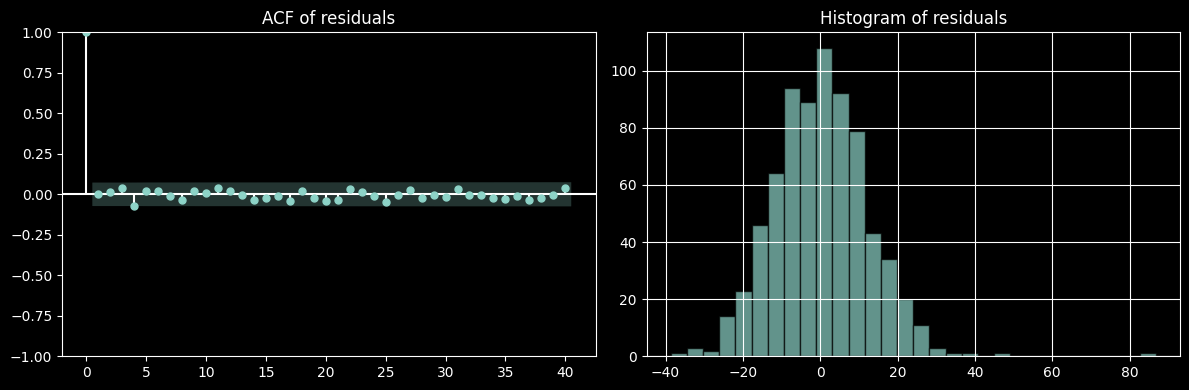

In [10]:
resid = fit_best.resid
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(resid, lags=40, ax=axes[0], title="ACF of residuals")
resid.hist(ax=axes[1], bins=30, edgecolor="black", alpha=0.7)
axes[1].set_title("Histogram of residuals")
plt.tight_layout()
plt.show()

In [11]:
lb = acorr_ljungbox(resid, lags=20, return_df=True)
print("Ljung-Box test (residuals):")
print(lb[["lb_stat", "lb_pvalue"]].head(10))
print("\nIf p-values are above 0.05, we do not reject white noise → residuals are consistent with WN.")

Ljung-Box test (residuals):
     lb_stat  lb_pvalue
1   0.006742   0.934559
2   0.129896   0.937116
3   1.091020   0.779242
4   4.932649   0.294278
5   5.327576   0.377223
6   5.598371   0.469648
7   5.678463   0.577754
8   6.756298   0.563140
9   7.020924   0.634941
10  7.110732   0.714951

If p-values are above 0.05, we do not reject white noise → residuals are consistent with WN.


### 6.2 Forecast evaluation (train/test split)

In [12]:
test_frac = 0.15
n_test = int(len(y) * test_frac)
train = y.iloc[:-n_test]
test = y.iloc[-n_test:]

model_f = ARIMA(train, order=best_order)
fit_f = model_f.fit()
forecast = fit_f.forecast(steps=n_test)

rmse = np.sqrt(np.mean((test.values - forecast.values) ** 2))
mae = np.mean(np.abs(test.values - forecast.values))
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE:  {mae:.4f}")

Test RMSE: 68.0918
Test MAE:  57.5755


/Users/nguyennghia/miniconda3/envs/vitaldb/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/nguyennghia/miniconda3/envs/vitaldb/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/nguyennghia/miniconda3/envs/vitaldb/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


### 6.3 Rolling one-step-ahead forecasts

The multi-step forecast above looks like a straight line because the model predicts *far into the future* from a single fit: the forecast mean reverts to the long-run mean. To get forecasts that **track** the test data, we use **rolling one-step-ahead** forecasts: at each time step we predict only the next value (and optionally re-estimate the model using all data up to that point). This way each prediction uses the most recent information and follows the series more closely.

/Users/nguyennghia/miniconda3/envs/vitaldb/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/nguyennghia/miniconda3/envs/vitaldb/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/nguyennghia/miniconda3/envs/vitaldb/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/nguyennghia/miniconda3/envs/vitaldb/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/nguyennghia/miniconda3/envs/vitaldb/lib/python3.10/site-p

Rolling 1-step (re-estimate each step):
  Test RMSE: 12.3030
  Test MAE:  9.6345


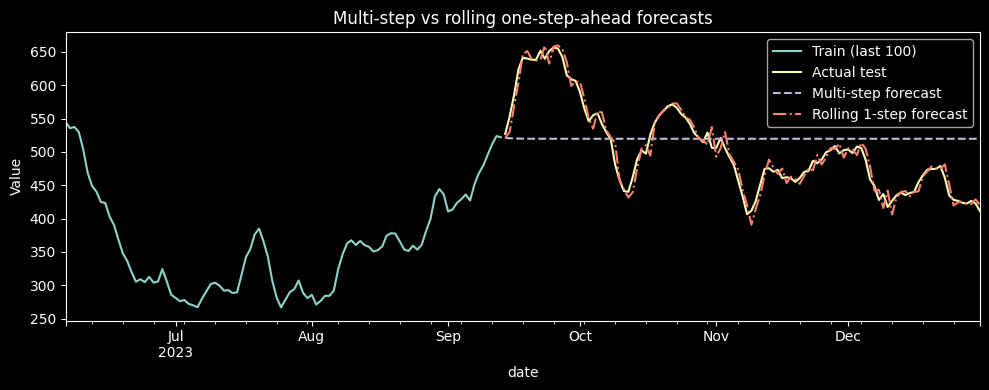

In [14]:
# Rolling one-step-ahead forecasts (re-estimate model each step)
rolling_preds = []
for i in range(n_test):
    # Data available up to (train end + i - 1); predict step (train end + i)
    hist = y.iloc[: -(n_test - i)]
    model_roll = ARIMA(hist, order=best_order)
    fit_roll = model_roll.fit()
    pred = fit_roll.forecast(steps=1)
    rolling_preds.append(pred.values[0])

rolling_forecast = pd.Series(rolling_preds, index=test.index)
rmse_roll = np.sqrt(np.mean((test.values - rolling_forecast.values) ** 2))
mae_roll = np.mean(np.abs(test.values - rolling_forecast.values))
print("Rolling 1-step (re-estimate each step):")
print(f"  Test RMSE: {rmse_roll:.4f}")
print(f"  Test MAE:  {mae_roll:.4f}")

# Plot: multi-step vs rolling 1-step vs actual
train.iloc[-100:].plot(label="Train (last 100)", legend=True)
test.plot(label="Actual test", legend=True)
pd.Series(forecast.values, index=test.index).plot(label="Multi-step forecast", legend=True, linestyle="--")
rolling_forecast.plot(label="Rolling 1-step forecast", legend=True, linestyle="-.")
plt.title("Multi-step vs rolling one-step-ahead forecasts")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

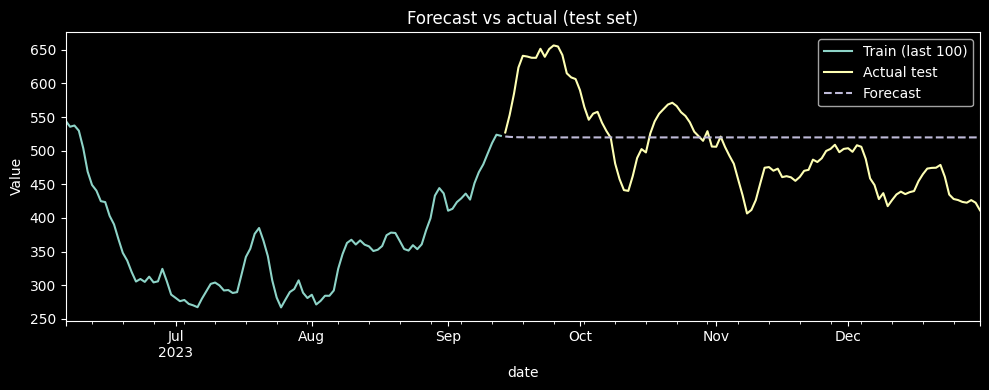

In [15]:
train.iloc[-100:].plot(label="Train (last 100)", legend=True)
test.plot(label="Actual test", legend=True)
pd.Series(forecast.values, index=test.index).plot(label="Forecast", legend=True, linestyle="--")
plt.title("Forecast vs actual (test set)")
plt.ylabel("Value")
plt.tight_layout()
plt.show()